# Dynamic Model Training and Evaluation (LSTM)

Treina e avalia um LSTM com os ficheiros CSV gerados em `outputs_dynamic`:
- `train_sequences.csv`
- `val_sequences.csv`
- `test_sequences.csv`

Inclui pequena grelha de tuning e exporta artefactos para `shared_models` compativeis com o backend.

## 1. Setup & Configuration

Import libraries, configure paths, and set up the environment.

In [33]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras

print('Python executable:', sys.executable)
print('Conda env:', os.environ.get('CONDA_DEFAULT_ENV'))
print('TensorFlow version:', tf.__version__)


def resolve_outputs_dir() -> Path:
    candidates = [Path('output'), Path('../dynamic/output'), Path('notebooks/dynamic/output')]
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Nao foi possivel localizar output.')


OUTPUT_DIR = resolve_outputs_dir()

ARTIFACT_MODEL = OUTPUT_DIR / 'lstm_wlasl100_best.keras'
ARTIFACT_LABELS = OUTPUT_DIR / 'label_encoder_wlasl100.joblib'
ARTIFACT_MEAN = OUTPUT_DIR / 'lstm_norm_mean.npy'
ARTIFACT_STD = OUTPUT_DIR / 'lstm_norm_std.npy'

print('OUTPUT_DIR =', OUTPUT_DIR)

Python executable: /opt/miniconda3/envs/aslai-clean/bin/python
Conda env: aslai-clean
TensorFlow version: 2.21.0
OUTPUT_DIR = /Users/nunoaraujo/MIA/SA/ASLAI--SA/TrabalhoPraticoNovo/notebooks/dynamic/output


## 2. Data Loading & Preprocessing

Load training, validation, and test sequences from CSV files. Encode labels and apply z-score normalization.

In [34]:
def load_split_from_csv(csv_path: Path) -> tuple[np.ndarray, np.ndarray]:
    split_df = pd.read_csv(csv_path)
    seq_len = int(split_df['seq_len'].iloc[0])
    n_features = int(split_df['n_features'].iloc[0])
    feature_df = split_df.drop(columns=['sample_id', 'seq_len', 'n_features', 'label'])

    X = feature_df.to_numpy(dtype=np.float32).reshape(len(split_df), seq_len, n_features)
    y = split_df['label'].astype(str).to_numpy()
    return X, y


X_train, y_train = load_split_from_csv(OUTPUT_DIR / 'train_sequences.csv')
X_val, y_val = load_split_from_csv(OUTPUT_DIR / 'val_sequences.csv')
X_test, y_test = load_split_from_csv(OUTPUT_DIR / 'test_sequences.csv')

print('Shapes:')
print(' X_train:', X_train.shape, '| y_train:', y_train.shape)
print(' X_val  :', X_val.shape, '| y_val  :', y_val.shape)
print(' X_test :', X_test.shape, '| y_test :', y_test.shape)

label_encoder = LabelEncoder()
y_train_idx = label_encoder.fit_transform(y_train)
y_val_idx = label_encoder.transform(y_val)
y_test_idx = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)
norm_mean = X_train.mean(axis=(0, 1))
norm_std = X_train.std(axis=(0, 1))
norm_std = np.where(norm_std < 1e-6, 1.0, norm_std)

X_train_n = (X_train - norm_mean) / norm_std
X_val_n = (X_val - norm_mean) / norm_std
X_test_n = (X_test - norm_mean) / norm_std

y_train_oh = keras.utils.to_categorical(y_train_idx, num_classes=num_classes)
y_val_oh = keras.utils.to_categorical(y_val_idx, num_classes=num_classes)
y_test_oh = keras.utils.to_categorical(y_test_idx, num_classes=num_classes)

print('Classes:', num_classes)
print('NaN train:', np.isnan(X_train_n).sum())

Shapes:
 X_train: (1440, 30, 258) | y_train: (1440,)
 X_val  : (337, 30, 258) | y_val  : (337,)
 X_test : (258, 30, 258) | y_test : (258,)
Classes: 100
NaN train: 0


## 3. Training Utilities

Define callbacks (LiveTrainingPlot, ValMacroF1Callback), temporal augmentation functions, model builder, and the main train_model orchestration function.

In [ ]:
class LiveTrainingPlot(keras.callbacks.Callback):
    def __init__(self, title: str):
        super().__init__()
        self.title = title
        self.display_handle = None
        self.history: dict[str, list[float]] = {
            'loss': [],
            'val_loss': [],
            'accuracy': [],
            'val_accuracy': [],
            'train_macro_f1': [],
            'val_macro_f1': [],
        }

    def _build_figure(self, epoch: int) -> plt.Figure:
        epochs = range(1, len(self.history['loss']) + 1)
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        axes[0].plot(epochs, self.history['loss'], label='train loss', linewidth=2)
        axes[0].plot(epochs, self.history['val_loss'], label='val loss', linewidth=2)
        axes[0].set_title(f'{self.title} - Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].grid(alpha=0.3)
        axes[0].legend()

        axes[1].plot(epochs, self.history['accuracy'], label='train accuracy', linewidth=2)
        axes[1].plot(epochs, self.history['val_accuracy'], label='val accuracy', linewidth=2)
        axes[1].set_title(f'{self.title} - Accuracy')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].grid(alpha=0.3)
        axes[1].legend()

        axes[2].plot(epochs, self.history['train_macro_f1'], label='train macro-F1', linewidth=2)
        axes[2].plot(epochs, self.history['val_macro_f1'], label='val macro-F1', linewidth=2)
        axes[2].set_title(f'{self.title} - Macro-F1')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Macro-F1')
        axes[2].grid(alpha=0.3)
        axes[2].legend()

        fig.suptitle(f'{self.title} | epoch {epoch + 1}', fontsize=14)
        plt.tight_layout()
        return fig

    def on_epoch_end(self, epoch: int, logs: dict[str, float] | None = None) -> None:
        logs = logs or {}
        for key in self.history:
            value = logs.get(key)
            if value is not None:
                self.history[key].append(float(value))
            elif self.history[key]:
                self.history[key].append(self.history[key][-1])
            else:
                self.history[key].append(float('nan'))

        fig = self._build_figure(epoch)
        if self.display_handle is None:
            self.display_handle = display(fig, display_id=True)
        else:
            self.display_handle.update(fig)
        plt.close(fig)


class ValMacroF1Callback(keras.callbacks.Callback):
    def __init__(self, X_train: np.ndarray, y_train_idx: np.ndarray, X_val: np.ndarray, y_val_idx: np.ndarray):
        super().__init__()
        self.X_train = X_train
        self.y_train_idx = y_train_idx
        self.X_val = X_val
        self.y_val_idx = y_val_idx
        self.history: list[float] = []

    def on_epoch_end(self, _epoch: int, logs: dict[str, float] | None = None) -> None:
        _ = _epoch
        logs = logs or {}
        train_probs = self.model.predict(self.X_train, verbose=0)
        train_pred = train_probs.argmax(axis=1)
        train_macro_f1 = float(f1_score(self.y_train_idx, train_pred, average='macro'))
        val_probs = self.model.predict(self.X_val, verbose=0)
        val_pred = val_probs.argmax(axis=1)
        val_macro_f1 = float(f1_score(self.y_val_idx, val_pred, average='macro'))
        logs['train_macro_f1'] = train_macro_f1
        logs['val_macro_f1'] = val_macro_f1
        self.history.append(val_macro_f1)


def temporal_shift(seq: np.ndarray, shift: int) -> np.ndarray:
    if shift == 0:
        return seq
    out = np.empty_like(seq)
    if shift > 0:
        out[:shift] = seq[0]
        out[shift:] = seq[:-shift]
    else:
        k = -shift
        out[-k:] = seq[-1]
        out[:-k] = seq[k:]
    return out


def temporal_time_warp(seq: np.ndarray, scale: float) -> np.ndarray:
    t, f = seq.shape
    orig_idx = np.arange(t, dtype=np.float32)
    warped_idx = np.linspace(0, t - 1, int(max(2, round(t * scale))), dtype=np.float32)
    warped = np.empty((warped_idx.shape[0], f), dtype=np.float32)
    for feat in range(f):
        warped[:, feat] = np.interp(warped_idx, orig_idx, seq[:, feat]).astype(np.float32)

    if warped.shape[0] == t:
        return warped

    target_idx = np.linspace(0, warped.shape[0] - 1, t, dtype=np.float32)
    restored = np.empty((t, f), dtype=np.float32)
    for feat in range(f):
        restored[:, feat] = np.interp(target_idx, np.arange(warped.shape[0], dtype=np.float32), warped[:, feat]).astype(np.float32)
    return restored


def augment_training_sequences(
    X: np.ndarray,
    augment_prob: float = 0.8,
    max_shift: int = 2,
    noise_std: float = 0.01,
    min_scale: float = 0.85,
    max_scale: float = 1.15,
    seed: int = 42,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    X_aug = X.copy()

    for i in range(X_aug.shape[0]):
        if rng.random() > augment_prob:
            continue

        seq = X_aug[i]

        if rng.random() < 0.7:
            shift = int(rng.integers(-max_shift, max_shift + 1))
            seq = temporal_shift(seq, shift)

        if rng.random() < 0.7:
            scale = float(rng.uniform(min_scale, max_scale))
            seq = temporal_time_warp(seq, scale)

        if rng.random() < 0.9:
            seq = seq + rng.normal(0.0, noise_std, size=seq.shape).astype(np.float32)

        X_aug[i] = seq.astype(np.float32)

    return X_aug


def build_model(
    seq_len: int,
    n_features: int,
    n_classes: int,
    units: int,
    dropout: float,
    lr: float,
    l2_reg: float,
    bidirectional: bool,
) -> keras.Model:
    layers = [
        keras.layers.Input(shape=(seq_len, n_features)),
        keras.layers.Masking(mask_value=0.0),
    ]

    if bidirectional:
        layers.append(
            keras.layers.Bidirectional(
                keras.layers.LSTM(
                    max(32, units // 2),
                    return_sequences=False,
                    kernel_regularizer=keras.regularizers.l2(l2_reg),
                    recurrent_regularizer=keras.regularizers.l2(l2_reg),
                )
            )
        )
    else:
        layers.append(
            keras.layers.LSTM(
                units,
                return_sequences=False,
                kernel_regularizer=keras.regularizers.l2(l2_reg),
                recurrent_regularizer=keras.regularizers.l2(l2_reg),
            )
        )

    layers.extend(
        [
            keras.layers.Dropout(dropout),
            keras.layers.BatchNormalization(),
            keras.layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(l2_reg)),
            keras.layers.Dropout(dropout),
            keras.layers.BatchNormalization(),
            keras.layers.Dense(n_classes, activation='softmax'),
        ]
    )

    model = keras.Sequential(layers)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


def train_model(
    param_grid: list[dict],
    model_builder: callable,
    architecture_name: str,
    seed_offset: int = 42,
) -> tuple[pd.DataFrame, keras.Model, dict, float]:
    """
    Train models across a parameter grid with temporal augmentation.
    
    Args:
        param_grid: List of hyperparameter dicts (units, dropout, lr, batch_size, l2_reg)
        model_builder: Callable that takes a params dict and returns a built keras.Model
        architecture_name: Name for display (e.g., 'LSTM' or 'BiLSTM')
        seed_offset: Offset for random seed to ensure different augmentations across architectures
    
    Returns:
        Tuple of (results_df, best_model, best_params, best_score)
    """
    print(f'\n=== {architecture_name} Training with Temporal Augmentation ===')
    
    results = []
    best_model = None
    best_score = -1.0
    best_params = None

    for idx, params in enumerate(param_grid, start=1):
        print(f"\n=== {architecture_name} Config {idx}/{len(param_grid)}: {params} ===")
        tf.keras.backend.clear_session()

        X_train_aug = augment_training_sequences(
            X_train_n,
            augment_prob=0.8,
            max_shift=2,
            noise_std=0.01,
            min_scale=0.85,
            max_scale=1.15,
            seed=seed_offset + idx,
        )

        model = model_builder(params)

        macro_f1_cb = ValMacroF1Callback(X_train_n, y_train_idx, X_val_n, y_val_idx)
        callbacks = [
            macro_f1_cb,
            keras.callbacks.EarlyStopping(
                monitor='val_macro_f1',
                mode='max',
                patience=12,
                min_delta=0.001,
                restore_best_weights=True,
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_macro_f1',
                mode='max',
                factor=0.5,
                patience=4,
                min_lr=1e-6,
                verbose=1,
            ),
            LiveTrainingPlot(title=f"{architecture_name} Config {idx}/{len(param_grid)}"),
        ]

        history = model.fit(
            X_train_aug,
            y_train_oh,
            validation_data=(X_val_n, y_val_oh),
            epochs=30,
            batch_size=params['batch_size'],
            class_weight=class_weight_dict,
            verbose=0,
            callbacks=callbacks,
        )

        val_probs = model.predict(X_val_n, verbose=0)
        val_pred = val_probs.argmax(axis=1)
        val_acc = accuracy_score(y_val_idx, val_pred)
        best_epoch_val_macro_f1 = max(macro_f1_cb.history) if macro_f1_cb.history else float('nan')

        row = {
            **params,
            'epochs_ran': int(len(history.history.get('loss', []))),
            'val_accuracy': float(val_acc),
            'val_macro_f1': float(best_epoch_val_macro_f1),
        }
        results.append(row)
        print(
            'Val accuracy:',
            round(val_acc, 4),
            '| Val macro-F1:',
            round(best_epoch_val_macro_f1, 4),
        )

        if best_epoch_val_macro_f1 > best_score:
            best_score = best_epoch_val_macro_f1
            best_model = model
            best_params = params

    results_df = pd.DataFrame(results).sort_values(['val_macro_f1', 'val_accuracy'], ascending=False).reset_index(drop=True)
    results_df.to_csv(OUTPUT_DIR / f'{architecture_name.lower()}_tuning_results.csv', index=False)
    
    print(f'\n{architecture_name} Training Results:')
    display(results_df)
    print(f'Best {architecture_name} params:', best_params)
    
    return results_df, best_model, best_params, best_score


## 4. LSTM Training

Train LSTM models across a parameter grid with temporal augmentation. Track best configuration by validation macro-F1.

Class weights sample: {0: 1.1076923076923078, 1: 1.2, 2: 1.0285714285714285, 3: 1.0285714285714285, 4: 1.1076923076923078, 5: 0.96, 6: 0.8, 7: 1.0285714285714285, 8: 1.2, 9: 0.96}

=== LSTM Training with Temporal Augmentation ===

=== LSTM Config 1/6: {'units': 128, 'dropout': 0.15, 'lr': 0.001, 'batch_size': 32, 'l2_reg': 1e-05} ===


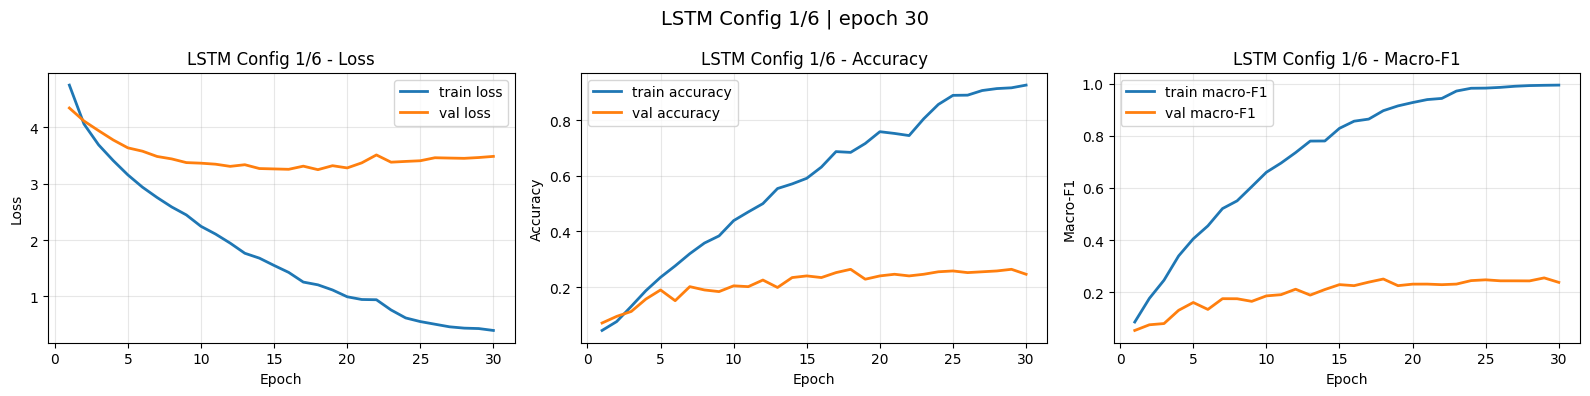


Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Val accuracy: 0.2641 | Val macro-F1: 0.2557 | Best epoch val_macro_f1: 0.2557

=== LSTM Config 2/6: {'units': 128, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'l2_reg': 1e-05} ===


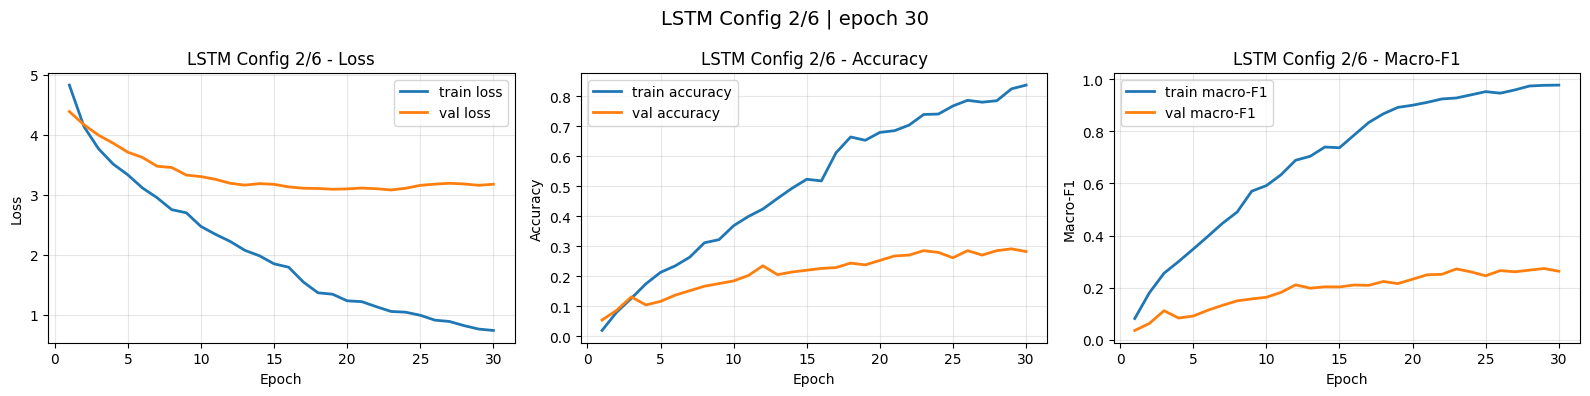


Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Val accuracy: 0.2908 | Val macro-F1: 0.2736 | Best epoch val_macro_f1: 0.2736

=== LSTM Config 3/6: {'units': 128, 'dropout': 0.25, 'lr': 0.0005, 'batch_size': 32, 'l2_reg': 0.0001} ===


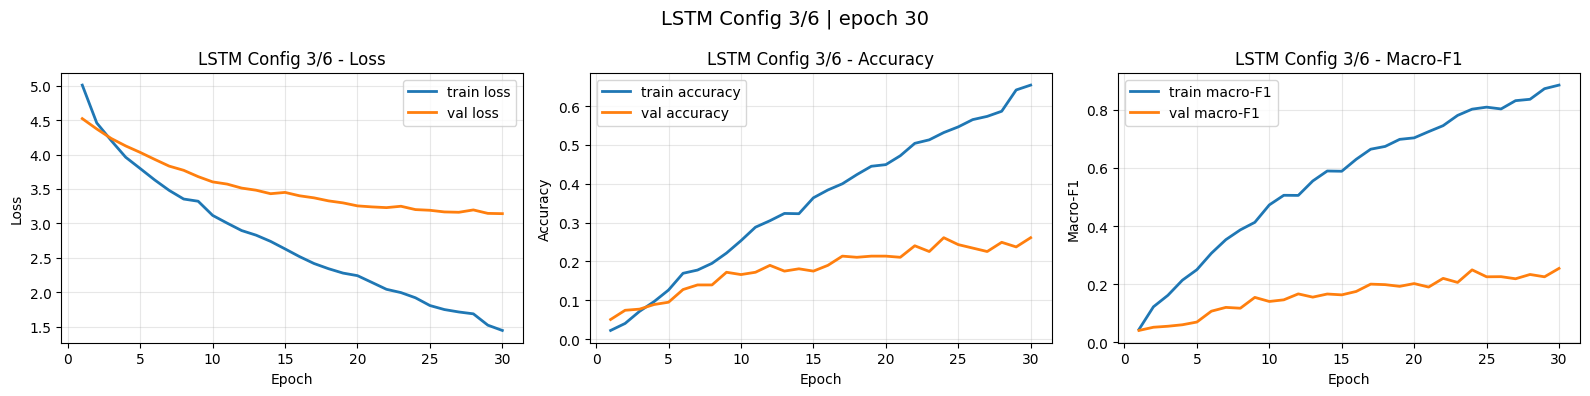


Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Val accuracy: 0.2611 | Val macro-F1: 0.2542 | Best epoch val_macro_f1: 0.2542

=== LSTM Config 4/6: {'units': 256, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32, 'l2_reg': 1e-05} ===


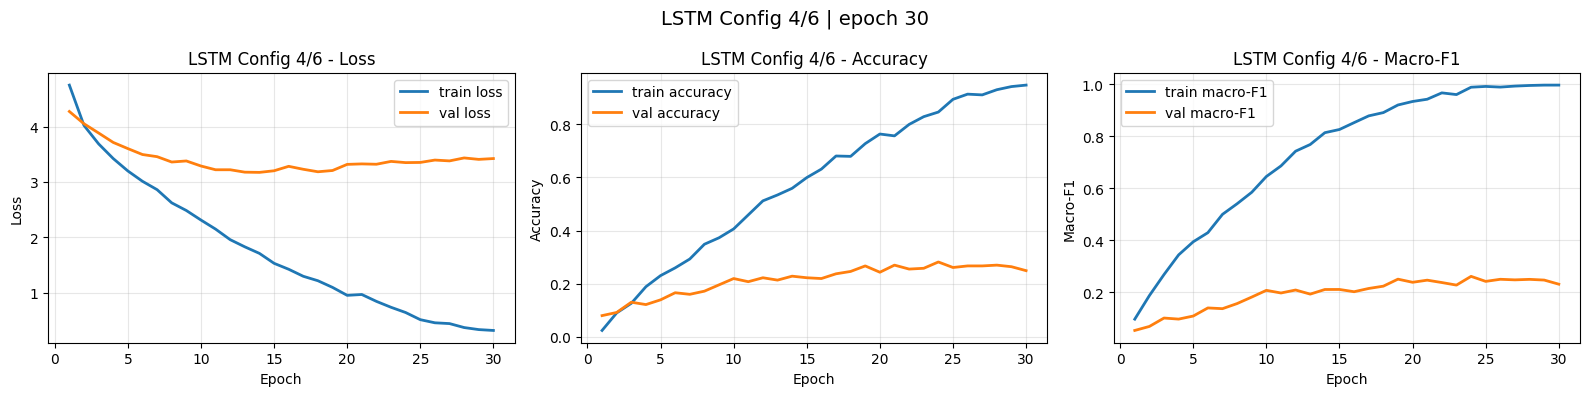


Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Val accuracy: 0.2819 | Val macro-F1: 0.2611 | Best epoch val_macro_f1: 0.2611

=== LSTM Config 5/6: {'units': 256, 'dropout': 0.25, 'lr': 0.0005, 'batch_size': 32, 'l2_reg': 0.0001} ===


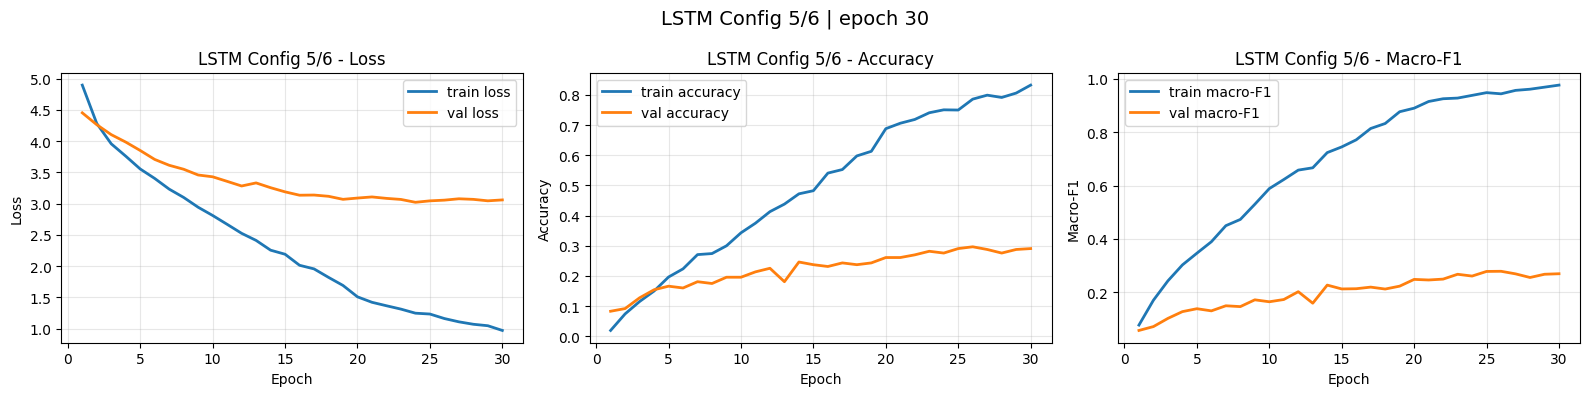


Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Val accuracy: 0.2908 | Val macro-F1: 0.278 | Best epoch val_macro_f1: 0.2786

=== LSTM Config 6/6: {'units': 256, 'dropout': 0.3, 'lr': 0.0002, 'batch_size': 16, 'l2_reg': 0.0005} ===


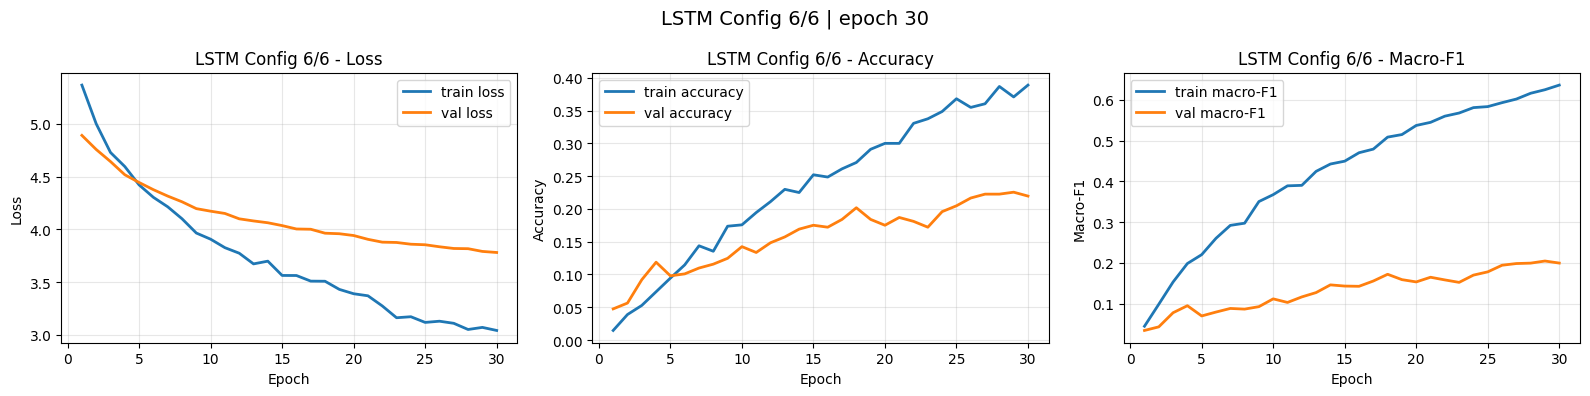


Epoch 8: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.

Epoch 22: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
Val accuracy: 0.2255 | Val macro-F1: 0.2043 | Best epoch val_macro_f1: 0.2043

LSTM Training Results:


,units,dropout,lr,batch_size,l2_reg,epochs_ran,val_accuracy,val_macro_f1,best_epoch_val_macro_f1
0,256,0.25,0.0005,32,0.00010,30,0.290801,0.278035,0.278586
1,128,0.20,0.0010,32,0.00001,30,0.290801,0.273565,0.273565
2,256,0.20,0.0010,32,0.00001,30,0.281899,0.261061,0.261061
3,128,0.15,0.0010,32,0.00001,30,0.264095,0.255677,0.255677
4,128,0.25,0.0005,32,0.00010,30,0.261128,0.254177,0.254177
5,256,0.30,0.0002,16,0.00050,30,0.225519,0.204332,0.204332


Best LSTM params: {'units': 256, 'dropout': 0.25, 'lr': 0.0005, 'batch_size': 32, 'l2_reg': 0.0001}


In [36]:
# LSTM Training with expanded param grid
param_grid_lstm = [
    {'units': 128, 'dropout': 0.15, 'lr': 1e-3, 'batch_size': 32, 'l2_reg': 1e-5},
    {'units': 128, 'dropout': 0.20, 'lr': 1e-3, 'batch_size': 32, 'l2_reg': 1e-5},
    {'units': 128, 'dropout': 0.25, 'lr': 5e-4, 'batch_size': 32, 'l2_reg': 1e-4},
    {'units': 256, 'dropout': 0.20, 'lr': 1e-3, 'batch_size': 32, 'l2_reg': 1e-5},
    {'units': 256, 'dropout': 0.25, 'lr': 5e-4, 'batch_size': 32, 'l2_reg': 1e-4},
    {'units': 256, 'dropout': 0.30, 'lr': 2e-4, 'batch_size': 16, 'l2_reg': 5e-4},
]

seq_len = X_train_n.shape[1]
n_features = X_train_n.shape[2]

classes = np.unique(y_train_idx)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_idx)
class_weight_dict = {int(cls): float(weight) for cls, weight in zip(classes, class_weights)}

print('Class weights sample:', dict(list(class_weight_dict.items())[:10]))


def build_lstm_model(params: dict) -> keras.Model:
    """Build an LSTM model with the given hyperparameters."""
    return build_model(
        seq_len=seq_len,
        n_features=n_features,
        n_classes=num_classes,
        units=params['units'],
        dropout=params['dropout'],
        lr=params['lr'],
        l2_reg=params['l2_reg'],
        bidirectional=False,
    )


results_df_lstm, best_model_lstm, best_params_lstm, best_score_lstm = train_model(
    param_grid=param_grid_lstm,
    model_builder=build_lstm_model,
    architecture_name='LSTM',
    seed_offset=42,
)


## 5. BiLSTM Training

Train BiLSTM models with lower regularization (less aggressive dropout and L2) to avoid over-constraining bidirectional capacity.


=== BiLSTM Training with Temporal Augmentation ===

=== BiLSTM Config 1/6: {'units': 128, 'dropout': 0.1, 'lr': 0.001, 'batch_size': 32, 'l2_reg': 5e-06} ===


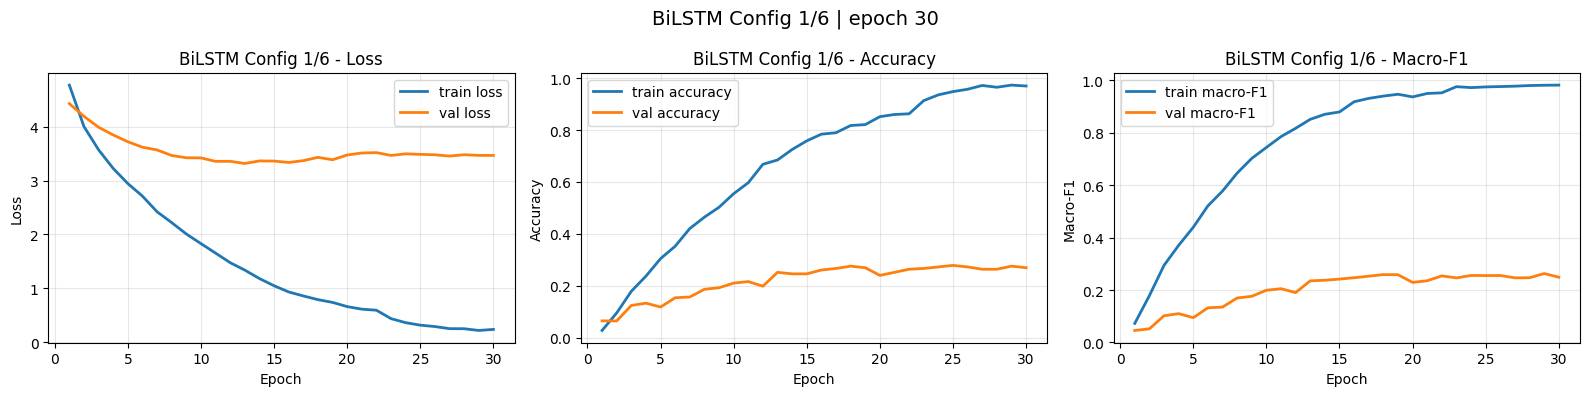


Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Val accuracy: 0.276 | Val macro-F1: 0.2629 | Best epoch val_macro_f1: 0.2629

=== BiLSTM Config 2/6: {'units': 128, 'dropout': 0.15, 'lr': 0.001, 'batch_size': 32, 'l2_reg': 5e-06} ===


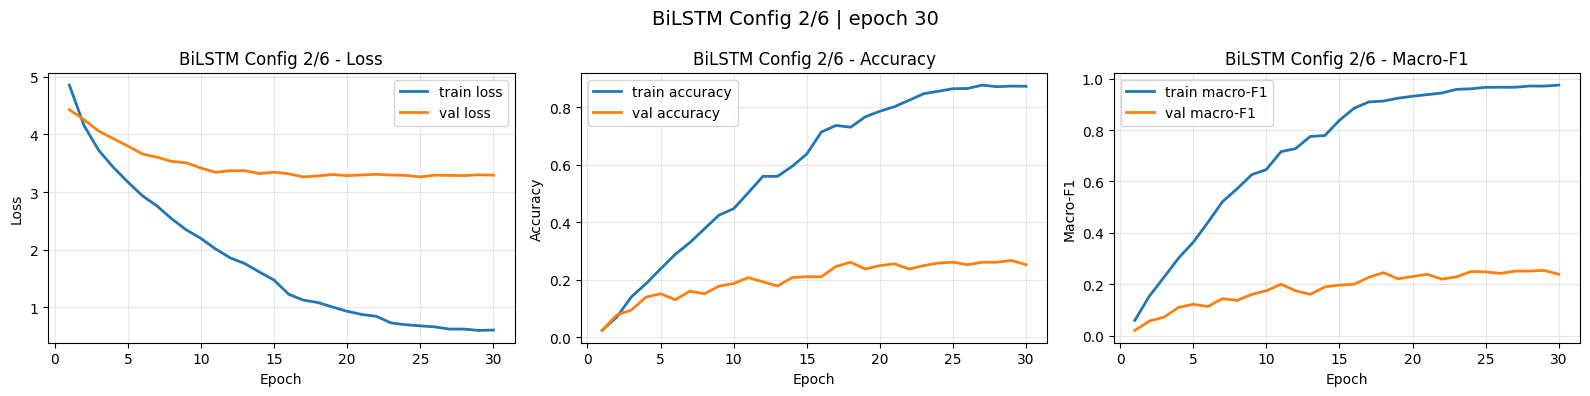


Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Val accuracy: 0.2671 | Val macro-F1: 0.2534 | Best epoch val_macro_f1: 0.2534

=== BiLSTM Config 3/6: {'units': 160, 'dropout': 0.1, 'lr': 0.001, 'batch_size': 32, 'l2_reg': 1e-05} ===


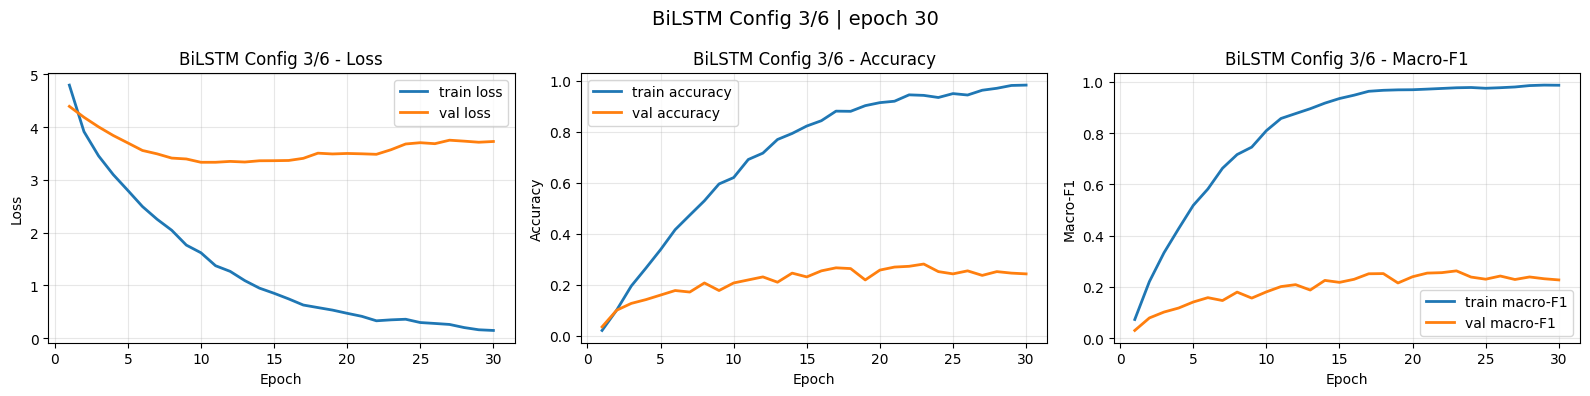


Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Val accuracy: 0.2819 | Val macro-F1: 0.2624 | Best epoch val_macro_f1: 0.2624

=== BiLSTM Config 4/6: {'units': 160, 'dropout': 0.15, 'lr': 0.0005, 'batch_size': 32, 'l2_reg': 1e-05} ===


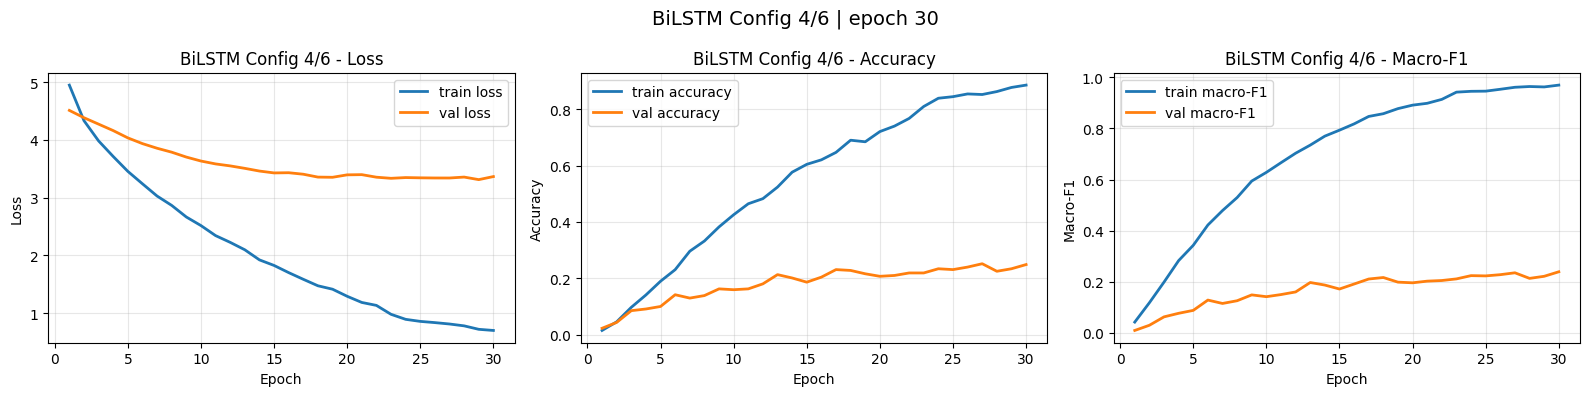


Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Val accuracy: 0.2493 | Val macro-F1: 0.2391 | Best epoch val_macro_f1: 0.2391

=== BiLSTM Config 5/6: {'units': 256, 'dropout': 0.15, 'lr': 0.001, 'batch_size': 32, 'l2_reg': 5e-06} ===


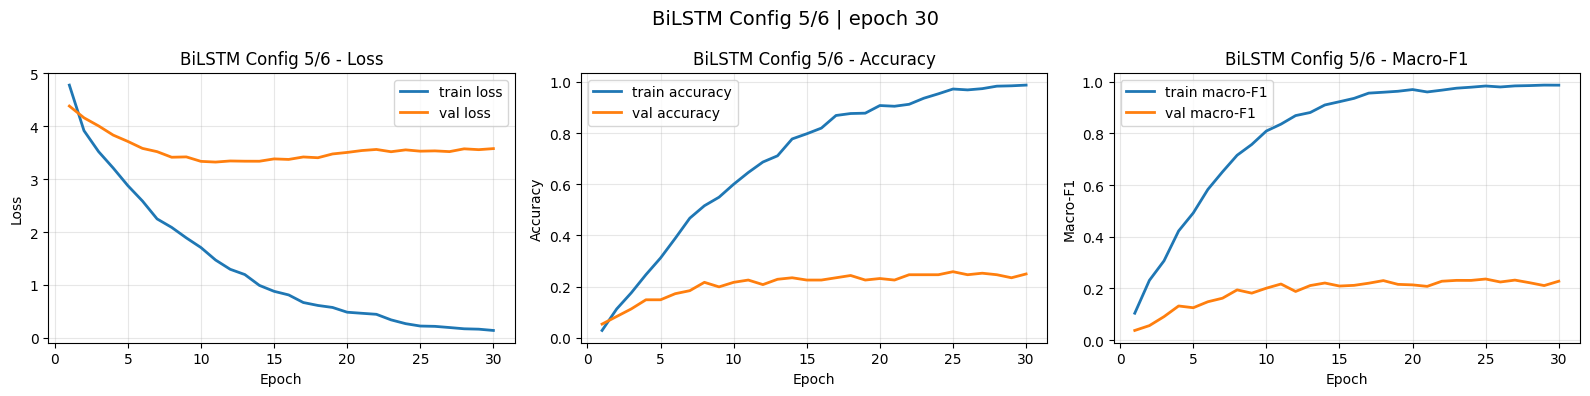


Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Val accuracy: 0.2582 | Val macro-F1: 0.2364 | Best epoch val_macro_f1: 0.2364

=== BiLSTM Config 6/6: {'units': 256, 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 32, 'l2_reg': 1e-05} ===


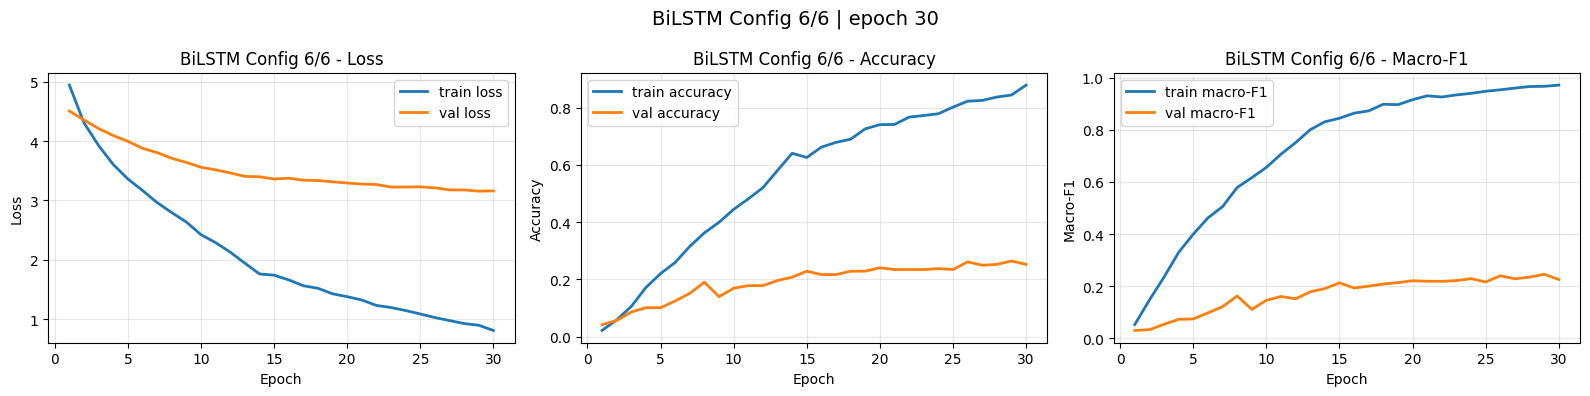


Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Val accuracy: 0.2641 | Val macro-F1: 0.2459 | Best epoch val_macro_f1: 0.2459

BiLSTM Training Results:


,units,dropout,lr,batch_size,l2_reg,epochs_ran,val_accuracy,val_macro_f1,best_epoch_val_macro_f1
0,128,0.10,0.0010,32,0.000005,30,0.275964,0.262863,0.262863
1,160,0.10,0.0010,32,0.000010,30,0.281899,0.262350,0.262350
2,128,0.15,0.0010,32,0.000005,30,0.267062,0.253425,0.253425
3,256,0.20,0.0005,32,0.000010,30,0.264095,0.245915,0.245915
4,160,0.15,0.0005,32,0.000010,30,0.249258,0.239097,0.239097
5,256,0.15,0.0010,32,0.000005,30,0.258160,0.236447,0.236447


Best BiLSTM params: {'units': 128, 'dropout': 0.1, 'lr': 0.001, 'batch_size': 32, 'l2_reg': 5e-06}


In [37]:
# BiLSTM Training with lower regularization (less aggressive)
param_grid_bilstm = [
    {'units': 128, 'dropout': 0.10, 'lr': 1e-3, 'batch_size': 32, 'l2_reg': 5e-6},
    {'units': 128, 'dropout': 0.15, 'lr': 1e-3, 'batch_size': 32, 'l2_reg': 5e-6},
    {'units': 160, 'dropout': 0.10, 'lr': 1e-3, 'batch_size': 32, 'l2_reg': 1e-5},
    {'units': 160, 'dropout': 0.15, 'lr': 5e-4, 'batch_size': 32, 'l2_reg': 1e-5},
    {'units': 256, 'dropout': 0.15, 'lr': 1e-3, 'batch_size': 32, 'l2_reg': 5e-6},
    {'units': 256, 'dropout': 0.20, 'lr': 5e-4, 'batch_size': 32, 'l2_reg': 1e-5},
]


def build_bilstm_model(params: dict) -> keras.Model:
    """Build a BiLSTM model with the given hyperparameters and lower regularization."""
    return build_model(
        seq_len=seq_len,
        n_features=n_features,
        n_classes=num_classes,
        units=params['units'],
        dropout=params['dropout'],
        lr=params['lr'],
        l2_reg=params['l2_reg'],
        bidirectional=True,
    )


results_df_bilstm, best_model_bilstm, best_params_bilstm, best_score_bilstm = train_model(
    param_grid=param_grid_bilstm,
    model_builder=build_bilstm_model,
    architecture_name='BiLSTM',
    seed_offset=100,
)


## 6. Model Comparison

Compare best LSTM and BiLSTM models. Select the overall winner based on validation macro-F1 score.

In [38]:
# Compare best models from both approaches
print('\n=== Comparison: Best LSTM vs Best BiLSTM ===')
comparison_data = {
    'model_type': ['LSTM', 'BiLSTM'],
    'best_val_accuracy': [float(best_score_lstm) if best_score_lstm > -1 else 0, best_score_bilstm],
    'best_val_macro_f1': [
        max([r['val_macro_f1'] for r in results_df_lstm.to_dict('records')]) if not results_df_lstm.empty else 0,
        max([r['val_macro_f1'] for r in results_df_bilstm.to_dict('records')]) if not results_df_bilstm.empty else 0,
    ],
    'best_params': [best_params_lstm, best_params_bilstm],
}
comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

# Choose best model overall
if best_score_lstm >= best_score_bilstm:
    print(f'\nChosen: LSTM (val_macro_f1={best_score_lstm:.4f})')
    best_model = best_model_lstm
    best_params = best_params_lstm
else:
    print(f'\nChosen: BiLSTM (val_macro_f1={best_score_bilstm:.4f})')
    best_model = best_model_bilstm
    best_params = best_params_bilstm


=== Comparison: Best LSTM vs Best BiLSTM ===


,model_type,best_val_accuracy,best_val_macro_f1,best_params
0,LSTM,0.278035,0.278035,"{'units': 256, 'dropout': 0.25, 'lr': 0.0005, ..."
1,BiLSTM,0.262863,0.262863,"{'units': 128, 'dropout': 0.1, 'lr': 0.001, 'b..."



Chosen: LSTM (val_macro_f1=0.2780)


## 7. Test Evaluation & Analysis

Evaluate the selected best model on test data. Generate per-class metrics, confusion matrix, and export artifacts for backend deployment.

Test accuracy: 0.2791
Test macro-F1: 0.2616

Classification report:
              precision    recall  f1-score   support

    accident       0.33      0.33      0.33         3
      africa       0.25      0.33      0.29         3
         all       0.00      0.00      0.00         3
       apple       0.67      1.00      0.80         2
  basketball       0.67      1.00      0.80         2
         bed       0.50      0.50      0.50         2
      before       0.00      0.00      0.00         4
        bird       0.33      0.50      0.40         2
    birthday       0.33      0.33      0.33         3
       black       0.33      0.33      0.33         3
        blue       0.00      0.00      0.00         2
        book       0.60      0.75      0.67         4
     bowling       0.00      0.00      0.00         2
       brown       0.00      0.00      0.00         2
         but       0.00      0.00      0.00         3
         can       0.25      0.50      0.33         2
       candy 

/opt/miniconda3/envs/aslai-clean/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/aslai-clean/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/aslai-clean/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

,class,precision,recall,f1,support
99,yes,0.0,0.0,0.0,3
71,pizza,0.0,0.0,0.0,3
29,dance,0.0,0.0,0.0,2
30,dark,0.0,0.0,0.0,3
70,pink,0.0,0.0,0.0,3
32,decide,0.0,0.0,0.0,2
33,doctor,0.0,0.0,0.0,3
34,dog,0.0,0.0,0.0,3
69,paper,0.0,0.0,0.0,2
67,orange,0.0,0.0,0.0,3



Top confusoes:


,true_class,confused_with,count
47,hot,thanksgiving,2
25,cousin,black,2
45,hearing,candy,2
73,school,year,2
8,blue,thursday,2
21,computer,table,2
12,but,language,2
63,now,want,2
62,no,dog,2
0,accident,africa,1


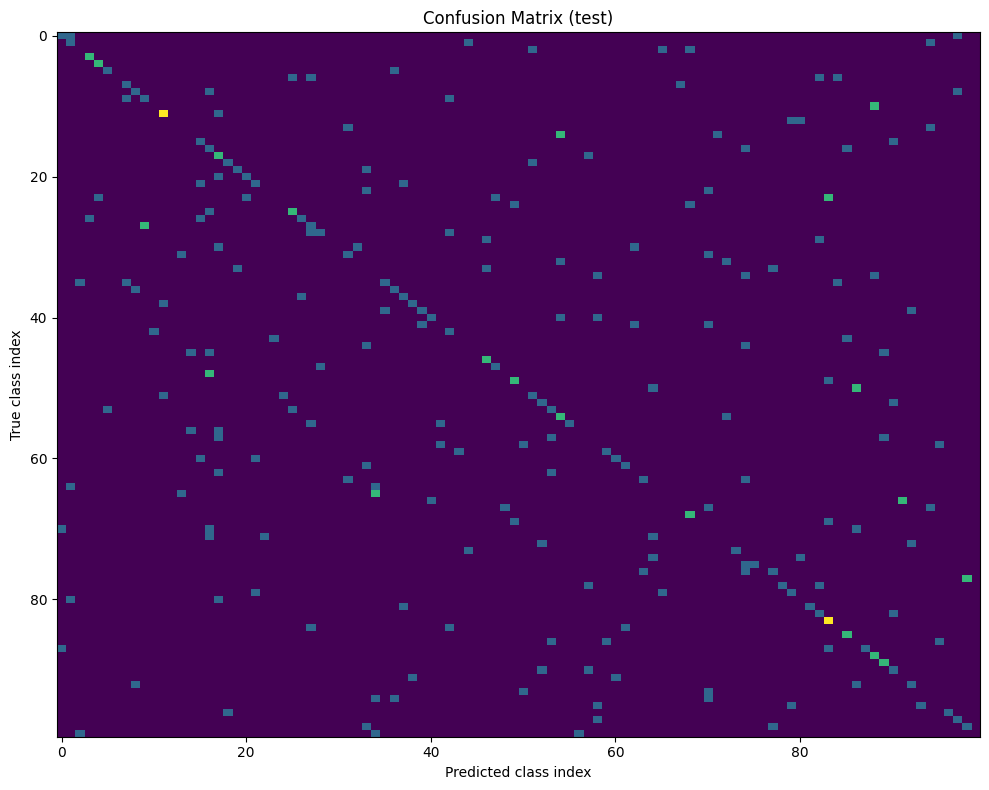


Top previsoes para 1 amostra de teste:
  wrong: 0.4012
  accident: 0.2224
  pink: 0.0636
  orange: 0.0374
  bed: 0.0343


In [39]:
if best_model is None:
    raise RuntimeError('Nenhum modelo treinado. Verifica os dados.')

test_probs = best_model.predict(X_test_n, verbose=0)
test_pred = test_probs.argmax(axis=1)
test_conf = test_probs.max(axis=1)

test_acc = accuracy_score(y_test_idx, test_pred)
test_f1 = f1_score(y_test_idx, test_pred, average='macro')

print('Test accuracy:', round(test_acc, 4))
print('Test macro-F1:', round(test_f1, 4))
print('\nClassification report:')
print(classification_report(y_test_idx, test_pred, target_names=label_encoder.classes_))

precision, recall, f1_vals, support = precision_recall_fscore_support(
    y_test_idx,
    test_pred,
    labels=np.arange(num_classes),
    zero_division=0,
)
per_class_df = pd.DataFrame(
    {
        'class': label_encoder.classes_,
        'precision': precision,
        'recall': recall,
        'f1': f1_vals,
        'support': support,
    }
).sort_values('f1', ascending=True)

cm = confusion_matrix(y_test_idx, test_pred, labels=np.arange(num_classes))
cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)

confusion_rows = []
for true_idx in range(num_classes):
    row = cm[true_idx]
    row_wo_diag = row.copy()
    row_wo_diag[true_idx] = 0
    pred_idx = int(np.argmax(row_wo_diag))
    if row_wo_diag[pred_idx] > 0:
        confusion_rows.append(
            {
                'true_class': label_encoder.classes_[true_idx],
                'confused_with': label_encoder.classes_[pred_idx],
                'count': int(row_wo_diag[pred_idx]),
            }
        )

top_confusions_df = pd.DataFrame(confusion_rows).sort_values('count', ascending=False).head(30)

confidence_df = pd.DataFrame(
    {
        'true_class': label_encoder.classes_[y_test_idx],
        'pred_class': label_encoder.classes_[test_pred],
        'confidence': test_conf,
        'correct': test_pred == y_test_idx,
    }
)

low_conf_threshold = 0.30
low_conf_mask = test_conf < low_conf_threshold
if int(low_conf_mask.sum()) > 0:
    low_conf_acc = accuracy_score(y_test_idx[low_conf_mask], test_pred[low_conf_mask])
    print(f'\nLow-confidence samples (<{low_conf_threshold:.2f}):', int(low_conf_mask.sum()))
    print('Low-confidence accuracy:', round(float(low_conf_acc), 4))
else:
    print(f'\nNo low-confidence samples below {low_conf_threshold:.2f}.')

best_model.save(ARTIFACT_MODEL)
joblib.dump(label_encoder, ARTIFACT_LABELS)
np.save(ARTIFACT_MEAN, norm_mean.astype(np.float32))
np.save(ARTIFACT_STD, norm_std.astype(np.float32))

per_class_df.to_csv(OUTPUT_DIR / 'test_per_class_metrics.csv', index=False)
cm_df.to_csv(OUTPUT_DIR / 'test_confusion_matrix.csv', index=True)
top_confusions_df.to_csv(OUTPUT_DIR / 'test_top_confusions.csv', index=False)
confidence_df.to_csv(OUTPUT_DIR / 'test_confidence_detail.csv', index=False)

print('\nArtefactos guardados:')
print(' -', ARTIFACT_MODEL)
print(' -', ARTIFACT_LABELS)
print(' -', ARTIFACT_MEAN)
print(' -', ARTIFACT_STD)
print('\nRelatorios guardados:')
print(' -', OUTPUT_DIR / 'lstm_tuning_results.csv')
print(' -', OUTPUT_DIR / 'test_per_class_metrics.csv')
print(' -', OUTPUT_DIR / 'test_confusion_matrix.csv')
print(' -', OUTPUT_DIR / 'test_top_confusions.csv')
print(' -', OUTPUT_DIR / 'test_confidence_detail.csv')

print('\nPiores classes por F1:')
display(per_class_df.head(10))

if not top_confusions_df.empty:
    print('\nTop confusoes:')
    display(top_confusions_df.head(10))

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(cm, interpolation='nearest', aspect='auto')
ax.set_title('Confusion Matrix (test)')
ax.set_xlabel('Predicted class index')
ax.set_ylabel('True class index')
plt.tight_layout()
plt.show()

# Validacao de inferencia offline
reloaded_model = keras.models.load_model(ARTIFACT_MODEL)
reloaded_labels = joblib.load(ARTIFACT_LABELS)
reloaded_mean = np.load(ARTIFACT_MEAN)
reloaded_std = np.load(ARTIFACT_STD)

sample = X_test[:1]
sample_n = (sample - reloaded_mean) / reloaded_std
probs = reloaded_model.predict(sample_n, verbose=0)[0]

top_k = min(5, probs.shape[0])
top_idx = probs.argsort()[-top_k:][::-1]
print('\nTop previsoes para 1 amostra de teste:')
for idx in top_idx:
    print(f'  {reloaded_labels.classes_[int(idx)]}: {float(probs[int(idx)]):.4f}')


## 8. Summary

Print final test metrics and report the output directory containing all artifacts and results.

In [40]:
print('Post-run summary:')
print(' test_acc =', round(float(test_acc), 4))
print(' test_macro_f1 =', round(float(test_f1), 4))
print(' zero_f1_classes =', int((per_class_df['f1'] == 0).sum()))
print(' reports_dir =', OUTPUT_DIR)

Post-run summary:
 test_acc = 0.2791
 test_macro_f1 = 0.2616
 zero_f1_classes = 43
 reports_dir = /Users/nunoaraujo/MIA/SA/ASLAI--SA/TrabalhoPraticoNovo/notebooks/dynamic/output
